# FactoryMind AI — Visual Quality Inspection EDA

This notebook validates and profiles the complete official **MVTec AD** dataset before any visual anomaly model is trained. The goal is to select one evidence-supported category for FactoryMind v1 while preserving the official normal-only training protocol and evaluation boundaries.

**Scope:** exploratory analysis only. No model fitting, feature-memory construction, threshold selection, or raw-image modification occurs here.

In [1]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'mvtec_ad'
EXPECTED_CATEGORIES = ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
TEXTURE_CATEGORIES = {'carpet', 'grid', 'leather', 'tile', 'wood'}
IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(f'MVTec AD dataset root not found: {DATASET_ROOT}')

print(f'Dataset root: {DATASET_ROOT.relative_to(PROJECT_ROOT)}')

Dataset root: data/raw/mvtec_ad


## 1. Dataset Structure Validation

The checks below fail explicitly if a category or required split is missing. For each anomalous test image, the official mask is expected at `ground_truth/<defect>/<image_stem>_mask.png`.

In [2]:
def image_files(path):
    return sorted(p for p in path.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)

actual_categories = sorted(p.name for p in DATASET_ROOT.iterdir() if p.is_dir())
missing_categories = sorted(set(EXPECTED_CATEGORIES) - set(actual_categories))
unexpected_categories = sorted(set(actual_categories) - set(EXPECTED_CATEGORIES))
structural_issues = []
mask_issues = []

for category in EXPECTED_CATEGORIES:
    category_root = DATASET_ROOT / category
    for required in [category_root / 'train' / 'good', category_root / 'test']:
        if not required.is_dir():
            structural_issues.append(f'Missing directory: {required.relative_to(PROJECT_ROOT)}')
    test_root = category_root / 'test'
    if test_root.is_dir():
        for defect_dir in sorted(p for p in test_root.iterdir() if p.is_dir() and p.name != 'good'):
            for image_path in image_files(defect_dir):
                mask_path = category_root / 'ground_truth' / defect_dir.name / f'{image_path.stem}_mask.png'
                if not mask_path.is_file():
                    mask_issues.append(str(mask_path.relative_to(PROJECT_ROOT)))

if missing_categories or unexpected_categories or structural_issues or mask_issues:
    raise RuntimeError({'missing_categories': missing_categories, 'unexpected_categories': unexpected_categories, 'structural_issues': structural_issues, 'missing_masks': mask_issues[:10]})

validation_summary = pd.DataFrame({
    'Check': ['Expected categories', 'Unexpected categories', 'Required train/good and test directories', 'Anomalous image-to-mask correspondence'],
    'Result': [f'PASS — {len(actual_categories)}/15 present', 'PASS — none', 'PASS — complete', 'PASS — complete'],
})
validation_summary

,Check,Result
0,Expected categories,PASS — 15/15 present
1,Unexpected categories,PASS — none
2,Required train/good and test directories,PASS — complete
3,Anomalous image-to-mask correspondence,PASS — complete


## 2. Category-Level Inventory

One image represents one visual inspection observation of an object or texture. Storage is the sum of source image and mask file sizes; it is not decoded in-memory size. Resolution statistics include train and test images, but no transformations are fitted.

In [3]:
inventory_rows = []
subtype_rows = []
image_records = []

for category in EXPECTED_CATEGORIES:
    root = DATASET_ROOT / category
    train_good = image_files(root / 'train' / 'good')
    test_dirs = sorted(p for p in (root / 'test').iterdir() if p.is_dir())
    test_good = image_files(root / 'test' / 'good')
    defect_dirs = [p for p in test_dirs if p.name != 'good']
    anomalous = [image for defect_dir in defect_dirs for image in image_files(defect_dir)]
    masks = sorted((root / 'ground_truth').glob('*/*_mask.png'))
    all_images = train_good + test_good + anomalous
    dimensions = []
    channels = Counter()
    formats = Counter()
    for path in all_images:
        with Image.open(path) as image:
            width, height = image.size
            dimensions.append((width, height))
            channels[image.mode] += 1
            formats[image.format] += 1
        split = 'train/good' if path in train_good else ('test/good' if path in test_good else f'test/{path.parent.name}')
        image_records.append({'category': category, 'path': path, 'split': split, 'defect_subtype': 'good' if path.parent.name == 'good' else path.parent.name, 'width': width, 'height': height})
    resolution_counts = Counter(dimensions)
    common_resolution, common_count = resolution_counts.most_common(1)[0]
    storage_bytes = sum(p.stat().st_size for p in all_images + masks)
    inventory_rows.append({
        'category': category, 'kind': 'texture' if category in TEXTURE_CATEGORIES else 'object',
        'train_images': len(train_good), 'train_good': len(train_good), 'test_images': len(test_good) + len(anomalous),
        'test_good': len(test_good), 'test_anomalous': len(anomalous), 'defect_subtypes': len(defect_dirs),
        'subtype_names': ', '.join(p.name for p in defect_dirs), 'ground_truth_masks': len(masks),
        'min_width': min(w for w, _ in dimensions), 'max_width': max(w for w, _ in dimensions),
        'min_height': min(h for _, h in dimensions), 'max_height': max(h for _, h in dimensions),
        'common_resolution': f'{common_resolution[0]}×{common_resolution[1]} ({common_count})',
        'unique_resolutions': len(resolution_counts), 'dimensions_consistent': len(resolution_counts) == 1,
        'channel_modes': ', '.join(f'{k}: {v}' for k, v in channels.items()), 'formats': ', '.join(formats),
        'storage_mb': storage_bytes / 1024**2,
    })
    for test_dir in test_dirs:
        subtype_rows.append({'category': category, 'test_subtype': test_dir.name, 'quality_label': 'normal' if test_dir.name == 'good' else 'anomalous', 'images': len(image_files(test_dir))})

inventory = pd.DataFrame(inventory_rows).sort_values(['kind', 'category']).reset_index(drop=True)
image_index = pd.DataFrame(image_records)
subtype_inventory = pd.DataFrame(subtype_rows)
inventory

,category,kind,train_images,train_good,test_images,test_good,test_anomalous,defect_subtypes,subtype_names,ground_truth_masks,min_width,max_width,min_height,max_height,common_resolution,unique_resolutions,dimensions_consistent,channel_modes,formats,storage_mb
0,bottle,object,209,209,83,20,63,3,"broken_large, broken_small, contamination",63,900,900,900,900,900×900 (292),1,True,RGB: 292,PNG,149.296837
1,cable,object,224,224,150,58,92,8,"bent_wire, cable_swap, combined, cut_inner_insulation, cut_outer_insulation, missing_cable, missing_wire, poke_insul...",92,1024,1024,1024,1024,1024×1024 (374),1,True,RGB: 374,PNG,481.772708
2,capsule,object,219,219,132,23,109,5,"crack, faulty_imprint, poke, scratch, squeeze",109,1000,1000,1000,1000,1000×1000 (351),1,True,RGB: 351,PNG,385.982739
3,hazelnut,object,391,391,110,40,70,4,"crack, cut, hole, print",70,1024,1024,1024,1024,1024×1024 (501),1,True,RGB: 501,PNG,588.955138
4,metal_nut,object,220,220,115,22,93,4,"bent, color, flip, scratch",93,700,700,700,700,700×700 (335),1,True,RGB: 335,PNG,158.158065
5,pill,object,267,267,167,26,141,7,"color, combined, contamination, crack, faulty_imprint, pill_type, scratch",141,800,800,800,800,800×800 (434),1,True,RGB: 434,PNG,262.313647
6,screw,object,320,320,160,41,119,5,"manipulated_front, scratch_head, scratch_neck, thread_side, thread_top",119,1024,1024,1024,1024,1024×1024 (480),1,True,L: 480,PNG,186.862927
7,toothbrush,object,60,60,42,12,30,1,defective,30,1024,1024,1024,1024,1024×1024 (102),1,True,RGB: 102,PNG,104.409769
8,transistor,object,213,213,100,60,40,4,"bent_lead, cut_lead, damaged_case, misplaced",40,1024,1024,1024,1024,1024×1024 (313),1,True,RGB: 313,PNG,384.496190
9,zipper,object,240,240,151,32,119,7,"broken_teeth, combined, fabric_border, fabric_interior, rough, split_teeth, squeezed_teeth",119,1024,1024,1024,1024,1024×1024 (391),1,True,L: 391,PNG,152.117017


In [4]:
dataset_totals = pd.Series({
    'categories': len(inventory),
    'train_good_images': int(inventory.train_good.sum()),
    'test_good_images': int(inventory.test_good.sum()),
    'test_anomalous_images': int(inventory.test_anomalous.sum()),
    'all_inspection_images': int(inventory.train_images.sum() + inventory.test_images.sum()),
    'ground_truth_masks': int(inventory.ground_truth_masks.sum()),
    'indexed_storage_gb': inventory.storage_mb.sum() / 1024,
})
dataset_totals.to_frame('value')

,value
categories,15.000000
train_good_images,3629.000000
test_good_images,467.000000
test_anomalous_images,1258.000000
all_inspection_images,5354.000000
ground_truth_masks,1258.000000
indexed_storage_gb,4.908908


## 3. Normal-Only Training Protocol

MVTec AD is not an ordinary supervised defect-classification dataset. The official training split contains only images under `train/good`; defect subtypes and masks occur in the evaluation split. The intended FactoryMind formulation is therefore:

**normal training images → learn normal visual appearance → compare unseen images with the normal representation → anomaly score + optional spatial anomaly map**

An anomaly score is a model-derived unusualness score, **not a probability**.

In [5]:
train_children = {category: sorted(p.name for p in (DATASET_ROOT / category / 'train').iterdir() if p.is_dir()) for category in EXPECTED_CATEGORIES}
assert all(children == ['good'] for children in train_children.values()), train_children
pd.DataFrame({'category': EXPECTED_CATEGORIES, 'train_subdirectories': [', '.join(train_children[c]) for c in EXPECTED_CATEGORIES], 'protocol_check': 'PASS — normal-only'})

,category,train_subdirectories,protocol_check
0,bottle,good,PASS — normal-only
1,cable,good,PASS — normal-only
2,capsule,good,PASS — normal-only
3,carpet,good,PASS — normal-only
4,grid,good,PASS — normal-only
5,hazelnut,good,PASS — normal-only
6,leather,good,PASS — normal-only
7,metal_nut,good,PASS — normal-only
8,pill,good,PASS — normal-only
9,screw,good,PASS — normal-only


## 4. Defect Subtype Analysis

Defect diversity describes evaluation coverage, not training-label richness. More subtypes may improve demonstration breadth but can also increase evaluation difficulty and does not automatically make a category preferable.

In [6]:
display(subtype_inventory.pivot_table(index=['category', 'quality_label'], columns='test_subtype', values='images', fill_value=0, aggfunc='sum'))
diversity = inventory[['category', 'defect_subtypes']].copy()
diversity['diversity_band'] = pd.cut(diversity.defect_subtypes, bins=[0, 3, 5, np.inf], labels=['few (1–3)', 'moderate (4–5)', 'high (6+)'])
diversity.sort_values(['defect_subtypes', 'category'])

test_subtype              bent  bent_lead  bent_wire  broken  broken_large  \
category   quality_label                                                     
bottle     anomalous         0          0          0       0            20   
           normal            0          0          0       0             0   
cable      anomalous         0          0         13       0             0   
           normal            0          0          0       0             0   
capsule    anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
carpet     anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
grid       anomalous        12          0          0      12             0   
           normal            0          0          0       0             0   
hazelnut   anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
leather    anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
metal_nut  anomalous        25          0          0       0             0   
           normal            0          0          0       0             0   
pill       anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
screw      anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
tile       anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
toothbrush anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
transistor anomalous         0         10          0       0             0   
           normal            0          0          0       0             0   
wood       anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   
zipper     anomalous         0          0          0       0             0   
           normal            0          0          0       0             0   

test_subtype              broken_small  broken_teeth  cable_swap  color  \
category   quality_label                                                  
bottle     anomalous                22             0           0      0   
           normal                    0             0           0      0   
cable      anomalous                 0             0          12      0   
           normal                    0             0           0      0   
capsule    anomalous                 0             0           0      0   
           normal                    0             0           0      0   
carpet     anomalous                 0             0           0     19   
           normal                    0             0           0      0   
grid       anomalous                 0             0           0      0   
           normal                    0             0           0      0   
hazelnut   anomalous                 0             0           0      0   
           normal                    0             0           0      0   
leather    anomalous                 0             0           0     19   
           normal                    0             0           0      0   
metal_nut  anomalous                 0             0           0     22   
           normal                    0             0           0      0   
pill       anomalous                 0             0           0     25   
           normal                    0             0           0      0   
scr

,category,defect_subtypes,diversity_band
7,toothbrush,1,few (1–3)
0,bottle,3,few (1–3)
3,hazelnut,4,moderate (4–5)
4,metal_nut,4,moderate (4–5)
8,transistor,4,moderate (4–5)
2,capsule,5,moderate (4–5)
10,carpet,5,moderate (4–5)
11,grid,5,moderate (4–5)
12,leather,5,moderate (4–5)
6,screw,5,moderate (4–5)


## 5. Image Dimensions and Preprocessing Implications

High-resolution images make patch-level defects visible, but decoding them at native resolution increases feature extraction time and patch-memory size. Notebook 15 should compare resize strategies against defect scale rather than choosing a final resolution in advance. Any pretrained backbone must receive its documented channel conversion and normalization. Raw files remain untouched.

In [7]:
dimension_view = inventory[['category', 'kind', 'min_width', 'max_width', 'min_height', 'max_height', 'common_resolution', 'unique_resolutions', 'dimensions_consistent', 'channel_modes', 'storage_mb']]
dimension_view.style.format({'storage_mb': '{:.1f}'})

,category,kind,min_width,max_width,min_height,max_height,common_resolution,unique_resolutions,dimensions_consistent,channel_modes,storage_mb
0,bottle,object,900,900,900,900,900×900 (292),1,True,RGB: 292,149.3
1,cable,object,1024,1024,1024,1024,1024×1024 (374),1,True,RGB: 374,481.8
2,capsule,object,1000,1000,1000,1000,1000×1000 (351),1,True,RGB: 351,386.0
3,hazelnut,object,1024,1024,1024,1024,1024×1024 (501),1,True,RGB: 501,589.0
4,metal_nut,object,700,700,700,700,700×700 (335),1,True,RGB: 335,158.2
5,pill,object,800,800,800,800,800×800 (434),1,True,RGB: 434,262.3
6,screw,object,1024,1024,1024,1024,1024×1024 (480),1,True,L: 480,186.9
7,toothbrush,object,1024,1024,1024,1024,1024×1024 (102),1,True,RGB: 102,104.4
8,transistor,object,1024,1024,1024,1024,1024×1024 (313),1,True,RGB: 313,384.5
9,zipper,object,1024,1024,1024,1024,1024×1024 (391),1,True,L: 391,152.1


## 6. Representative Visual Inspection

The deterministic sample below spans objects and textures. It shows one normal training image, one normal test image, and one anomalous test image per selected category.

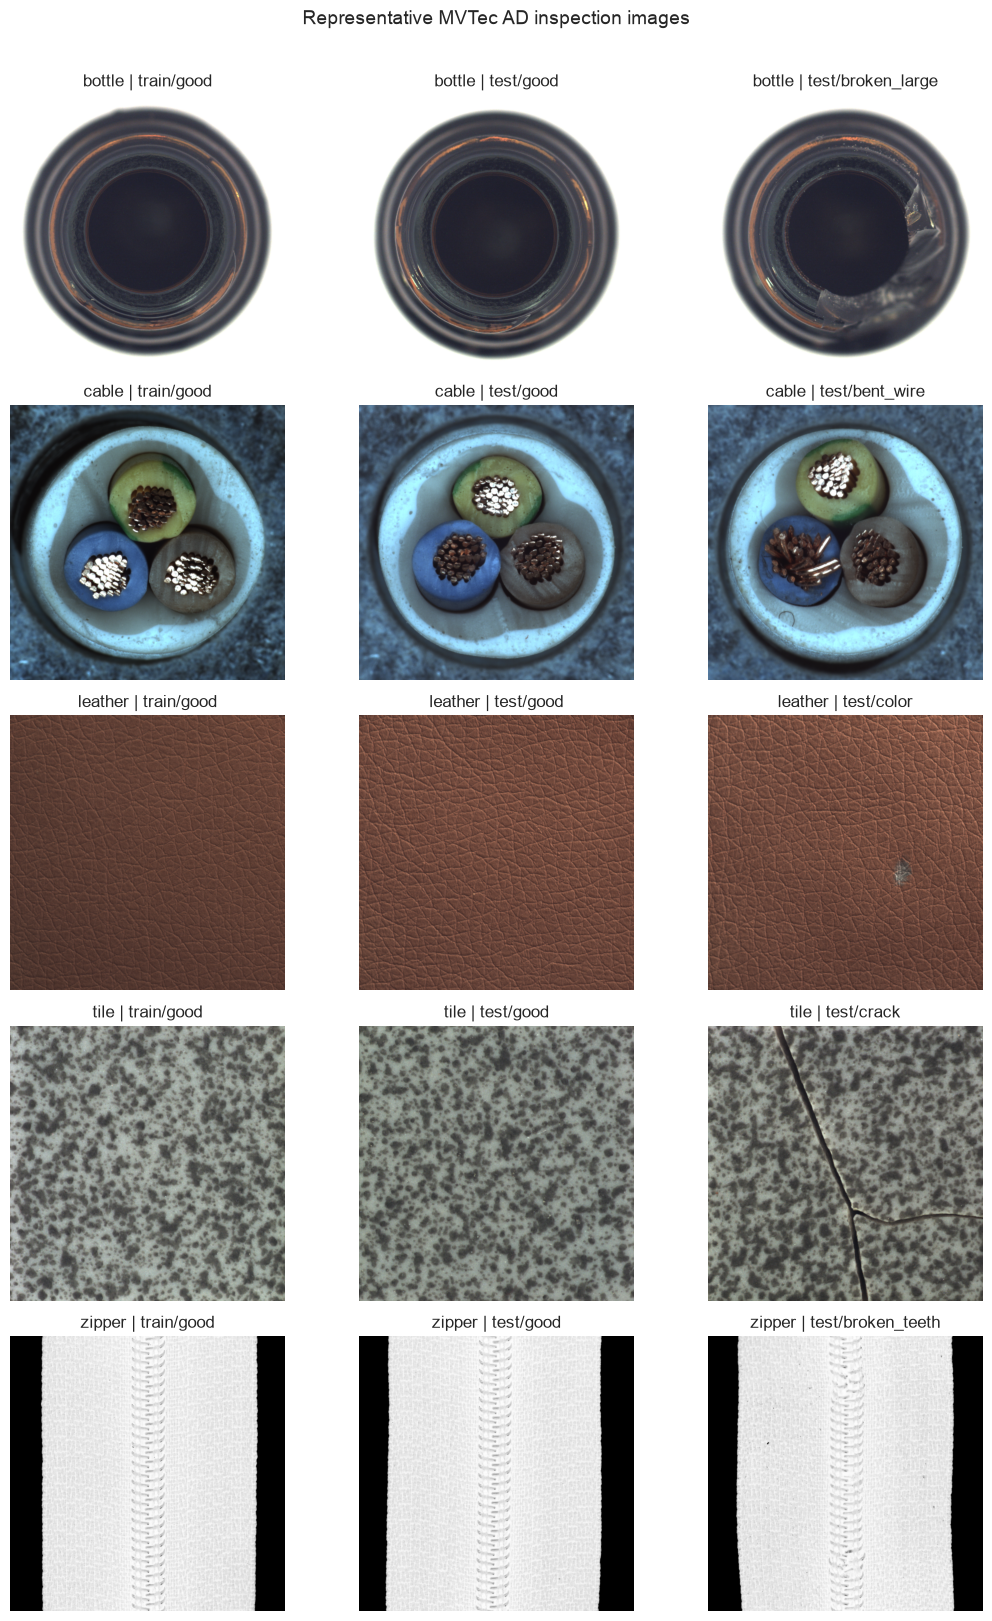

In [8]:
visual_categories = ['bottle', 'cable', 'leather', 'tile', 'zipper']
fig, axes = plt.subplots(len(visual_categories), 3, figsize=(11, 16))
for row, category in enumerate(visual_categories):
    category_rows = image_index[image_index.category == category]
    selections = [
        category_rows[category_rows.split == 'train/good'].iloc[0],
        category_rows[category_rows.split == 'test/good'].iloc[0],
        category_rows[category_rows.defect_subtype != 'good'].iloc[0],
    ]
    for col, sample in enumerate(selections):
        with Image.open(sample.path) as image:
            axes[row, col].imshow(image)
        axes[row, col].set_title(f"{category} | {sample.split}")
        axes[row, col].axis('off')
plt.suptitle('Representative MVTec AD inspection images', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 7. Ground-Truth Defect Annotations

These masks are official **ground-truth defect annotations**, not model-generated heatmaps. They are evaluation-only and will later support pixel-level localization metrics. They must never be model inputs.

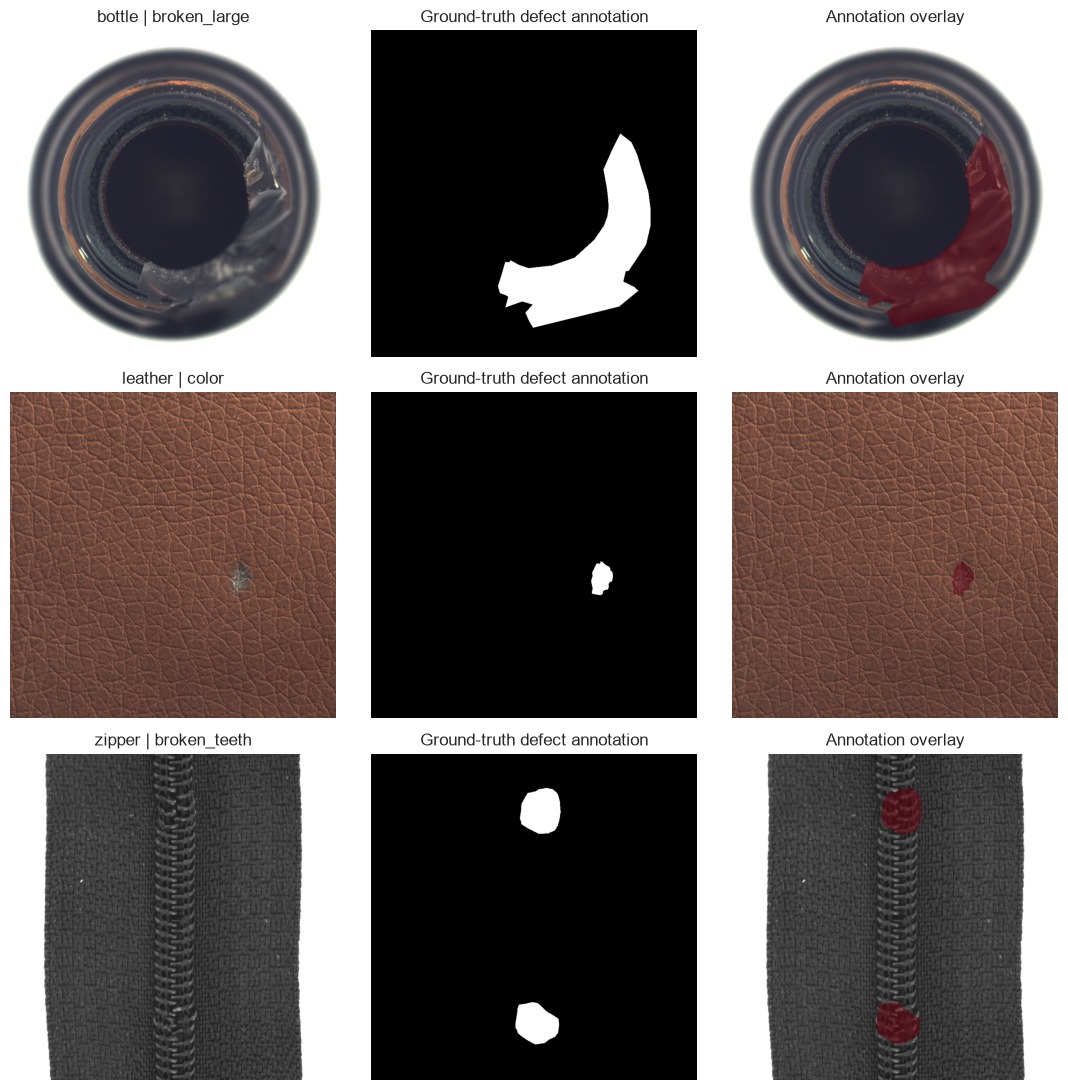

In [9]:
overlay_categories = ['bottle', 'leather', 'zipper']
fig, axes = plt.subplots(len(overlay_categories), 3, figsize=(11, 11))
for row, category in enumerate(overlay_categories):
    sample = image_index[(image_index.category == category) & (image_index.defect_subtype != 'good')].iloc[0]
    mask_path = DATASET_ROOT / category / 'ground_truth' / sample.defect_subtype / f'{sample.path.stem}_mask.png'
    with Image.open(sample.path) as source_image, Image.open(mask_path) as source_mask:
        image = np.asarray(source_image.convert('RGB'))
        mask = np.asarray(source_mask.convert('L')) > 0
    axes[row, 0].imshow(image); axes[row, 0].set_title(f'{category} | {sample.defect_subtype}')
    axes[row, 1].imshow(mask, cmap='gray'); axes[row, 1].set_title('Ground-truth defect annotation')
    axes[row, 2].imshow(image); axes[row, 2].imshow(mask, cmap='Reds', alpha=np.where(mask, 0.55, 0)); axes[row, 2].set_title('Annotation overlay')
    for axis in axes[row]: axis.axis('off')
plt.tight_layout()
plt.show()

## 8. Defect Size and Localization Difficulty

Mask area is summarized only to understand evaluation difficulty. It is not used as a model feature or category-performance signal. Small defect percentages imply that aggressive resizing may erase relevant evidence and that localization metrics are necessary.

,count,min,median,mean,max
category,,,,,
screw,119.000,0.099,0.288,0.335,1.011
capsule,109.000,0.037,0.429,1.109,8.079
leather,92.000,0.089,0.462,0.874,6.859
grid,57.000,0.188,0.601,0.945,3.582
pill,141.000,0.050,1.033,3.977,41.004
toothbrush,30.000,0.238,1.078,2.141,12.976
carpet,89.000,0.165,1.476,2.106,8.017
hazelnut,70.000,0.233,1.616,3.355,27.659
transistor,40.000,0.224,2.028,11.983,49.321


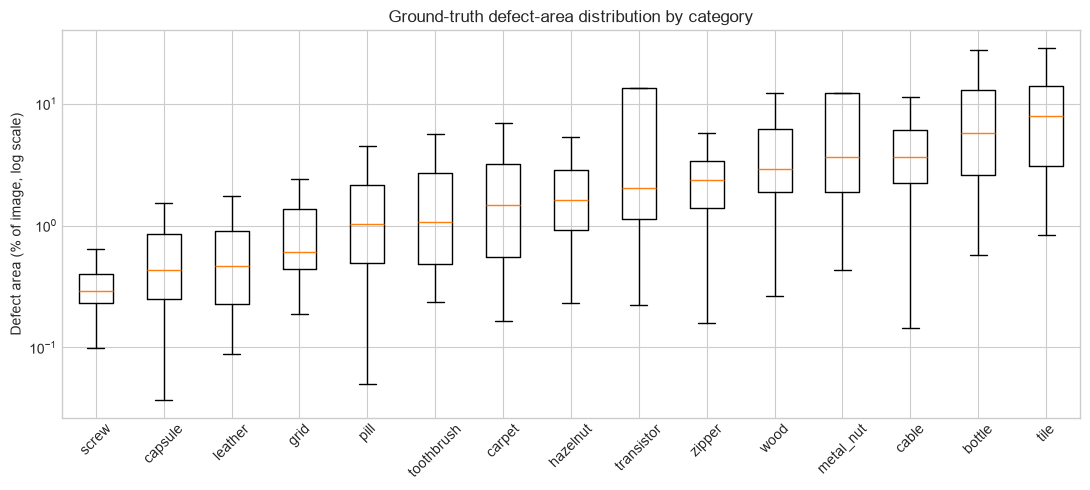

In [10]:
mask_rows = []
for category in EXPECTED_CATEGORIES:
    for mask_path in sorted((DATASET_ROOT / category / 'ground_truth').glob('*/*_mask.png')):
        with Image.open(mask_path) as source_mask:
            mask = np.asarray(source_mask.convert('L')) > 0
        mask_rows.append({'category': category, 'defect_subtype': mask_path.parent.name, 'mask_pixels': int(mask.sum()), 'image_pixels': int(mask.size), 'defect_area_pct': float(mask.mean() * 100)})
mask_stats = pd.DataFrame(mask_rows)
defect_size_summary = mask_stats.groupby('category').defect_area_pct.agg(['count', 'min', 'median', 'mean', 'max']).sort_values('median')
display(defect_size_summary.style.format('{:.3f}'))

fig, ax = plt.subplots(figsize=(11, 5))
ordered = defect_size_summary.index
ax.boxplot([mask_stats.loc[mask_stats.category == category, 'defect_area_pct'] for category in ordered], tick_labels=ordered, showfliers=False)
ax.set_yscale('log'); ax.set_ylabel('Defect area (% of image, log scale)'); ax.tick_params(axis='x', rotation=45)
ax.set_title('Ground-truth defect-area distribution by category')
plt.tight_layout(); plt.show()

## 9. Object-Like and Texture-Like Categories

The official MVTec organization contains five textures (`carpet`, `grid`, `leather`, `tile`, `wood`) and ten objects. Object inspection may depend on boundaries, alignment, pose, and component structure. Texture inspection emphasizes repeated patterns and localized surface deviations. Both are valid, but they create different preprocessing and explanation challenges.

In [11]:
inventory.groupby('kind').agg(categories=('category', 'count'), train_good=('train_good', 'sum'), test_anomalous=('test_anomalous', 'sum'), median_defect_subtypes=('defect_subtypes', 'median'), storage_mb=('storage_mb', 'sum')).round(1)

,categories,train_good,test_anomalous,median_defect_subtypes,storage_mb
kind,,,,,
object,10,2363,876,4.5,2854.4
texture,5,1266,382,5.0,2172.4


## 10. Leakage and Evaluation Guardrails

Future modeling must **not**:

- train on official test images or build the normal memory from `test/good`;
- fit normalization, PCA, dimensionality reduction, or other learned preprocessing on test data;
- use ground-truth masks during representation or reference fitting;
- use defect subtype labels as training targets for a normal-only anomaly detector;
- tune hyperparameters or thresholds directly against final test labels;
- select the winning category because it achieved the best test model score;
- leak filenames or directory labels into predictive features;
- augment before splitting in a way that creates near-duplicates across development partitions.

Official test images, labels, and masks remain final evaluation-only resources.

## 11. Leakage-Safe Development Strategy

1. Preserve the complete official test split for final evaluation.
2. Deterministically split only `train/good` when development diagnostics require held-out normal images.
3. Fit the backbone-dependent normal representation, PCA (if any), and patch memory only on the development-training portion.
4. Use held-out normal training images to check score stability, memory choices, and false-alert behavior.
5. Acknowledge that normal-only validation cannot fully optimize anomaly discrimination or localization.
6. Do not fabricate anomalous labels. Any later synthetic-anomaly experiment must be separately justified and audited.
7. Freeze preprocessing, model configuration, and threshold-development policy before final test evaluation.

## 12. Apple Silicon / Laptop Feasibility

The estimate below illustrates patch-memory scale after a hypothetical 256×256 feature grid with stride 16 and 384 float32 values per patch. It is a planning approximation—not a final preprocessing decision. Native-resolution extraction would create substantially more patches.

In [12]:
PATCHES_AT_256 = (256 // 16) ** 2
EMBEDDING_DIM = 384
feasibility = inventory[['category', 'kind', 'train_good', 'common_resolution', 'defect_subtypes', 'storage_mb']].copy()
feasibility['estimated_patches_at_256'] = feasibility.train_good * PATCHES_AT_256
feasibility['full_memory_mb_at_384d'] = feasibility.estimated_patches_at_256 * EMBEDDING_DIM * 4 / 1024**2
feasibility['10pct_coreset_mb'] = feasibility.full_memory_mb_at_384d * 0.10
feasibility.sort_values('full_memory_mb_at_384d').style.format({'storage_mb': '{:.1f}', 'full_memory_mb_at_384d': '{:.1f}', '10pct_coreset_mb': '{:.1f}'})

,category,kind,train_good,common_resolution,defect_subtypes,storage_mb,estimated_patches_at_256,full_memory_mb_at_384d,10pct_coreset_mb
7,toothbrush,object,60,1024×1024 (102),1,104.4,15360,22.5,2.2
0,bottle,object,209,900×900 (292),3,149.3,53504,78.4,7.8
8,transistor,object,213,1024×1024 (313),4,384.5,54528,79.9,8.0
2,capsule,object,219,1000×1000 (351),5,386.0,56064,82.1,8.2
4,metal_nut,object,220,700×700 (335),4,158.2,56320,82.5,8.2
1,cable,object,224,1024×1024 (374),8,481.8,57344,84.0,8.4
13,tile,texture,230,840×840 (347),5,335.4,58880,86.2,8.6
9,zipper,object,240,1024×1024 (391),7,152.1,61440,90.0,9.0
12,leather,texture,245,1024×1024 (369),5,501.1,62720,91.9,9.2
14,wood,texture,247,1024×1024 (326),5,475.4,63232,92.6,9.3


A frozen pretrained feature extractor is feasible category-by-category on Apple Silicon. PatchCore memory should use batched extraction and a measured coreset ratio. `toothbrush` is light but too narrow for the first portfolio module; `hazelnut` has the largest normal set; high-resolution categories require evidence-based resizing and defect-scale checks.

## 13. FactoryMind v1 Category-Selection Rubric

Scores are transparent EDA judgments from 1 (weak) to 5 (strong), not model results. The rubric balances industrial relevance, normal sample availability, defect diversity, localization usefulness, defect-size diversity, portfolio interpretability, compute feasibility, normal-only suitability, and future upload-plus-heatmap clarity.

In [13]:
candidate_scores = pd.DataFrame([
    ['zipper', 5, 4, 5, 5, 4, 5, 4, 5, 5],
    ['cable', 5, 4, 5, 5, 4, 4, 3, 4, 5],
    ['pill', 5, 4, 5, 5, 4, 5, 4, 4, 5],
    ['leather', 4, 4, 4, 5, 5, 5, 4, 5, 5],
    ['bottle', 5, 4, 3, 5, 4, 5, 5, 5, 5],
], columns=['category', 'industrial_relevance', 'normal_samples', 'defect_diversity', 'localization_value', 'defect_size_diversity', 'portfolio_clarity', 'compute_feasibility', 'normal_only_fit', 'product_heatmap_fit'])
candidate_scores['rubric_total'] = candidate_scores.iloc[:, 1:].sum(axis=1)
evidence = inventory[['category', 'train_good', 'test_anomalous', 'defect_subtypes', 'common_resolution', 'storage_mb']].merge(defect_size_summary[['median', 'min', 'max']], left_on='category', right_index=True)
candidate_comparison = candidate_scores.merge(evidence, on='category').sort_values('rubric_total', ascending=False)
candidate_comparison.style.format({'storage_mb': '{:.1f}', 'median': '{:.3f}', 'min': '{:.3f}', 'max': '{:.3f}'})

,category,industrial_relevance,normal_samples,defect_diversity,localization_value,defect_size_diversity,portfolio_clarity,compute_feasibility,normal_only_fit,product_heatmap_fit,rubric_total,train_good,test_anomalous,defect_subtypes,common_resolution,storage_mb,median,min,max
0,zipper,5,4,5,5,4,5,4,5,5,42,240,119,7,1024×1024 (391),152.1,2.354,0.159,11.831
2,pill,5,4,5,5,4,5,4,4,5,41,267,141,7,800×800 (434),262.3,1.033,0.050,41.004
3,leather,4,4,4,5,5,5,4,5,5,41,245,92,5,1024×1024 (369),501.1,0.462,0.089,6.859
4,bottle,5,4,3,5,4,5,5,5,5,41,209,63,3,900×900 (292),149.3,5.718,0.576,27.419
1,cable,5,4,5,5,4,4,3,4,5,39,224,92,8,1024×1024 (374),481.8,3.681,0.144,22.581


## 14. Selected Category: Zipper

**Recommendation: use `zipper` for FactoryMind Visual Quality Inspection v1.**

Why it is preferred:

- It is a concrete, recognizable industrial object with a clear inspection story.
- Its 240 normal training images are sufficient for a focused frozen-feature baseline without being the largest category.
- Seven defect subtypes provide high visual diversity while retaining a coherent product identity.
- All anomalous test images have pixel masks, enabling intuitive heatmaps and quantitative localization evaluation.
- Uniform 1024×1024 imagery supports deterministic preprocessing experiments, while the observed defect-size range makes resolution selection meaningful.
- It offers a strong image-upload → anomaly score → localized region portfolio experience without needing a supervised defect classifier.

Challenges include small or narrow defects, repeated tooth structure, and sensitivity to resizing. `cable` has greater subtype diversity but more complex configuration and alignment variation. `pill` is equally strong but has more anomalous evaluation images and fine appearance variation. `leather` is an excellent texture alternative, but zipper better demonstrates object-level product inspection. `bottle` is visually clear and compute-friendly but has only three defect subtypes.

## 15. Recommended Notebook 15 Modeling Plan

**Baseline:** frozen pretrained CNN features (for example ResNet-18 or Wide ResNet features), deterministic preprocessing, normal-only patch/image embeddings, and nearest-reference distance scoring. Compare image-level pooling choices without using test labels for selection.

**Stronger model:** PatchCore with a pretrained backbone, multi-layer patch embeddings, a normal patch memory bank, and measured coreset reduction. **Comparison:** PaDiM if its Gaussian feature model remains tractable and reproducible.

Notebook 15 should document image resize/crop evidence, pretrained normalization, batch feature extraction, patch geometry, memory consumption, image-score aggregation, spatial-map upsampling, and a leakage-safe threshold-development policy. No anomaly score should be called a probability.

Recommended final evaluation metrics: image ROC-AUC and Average Precision as primary ranking metrics; precision, recall, and F1 only after a frozen threshold; pixel ROC-AUC and correctly implemented PRO/AUPRO for localization. Accuracy should not be primary.

## 16. Future Product Direction

**inspection image → validated preprocessing → visual anomaly inference → non-probabilistic anomaly score → thresholded assessment → spatial anomaly heatmap → development-stage warning and interpretation**

The future API contract should follow actual model capabilities and is not frozen here. The product must not claim failure probability, defect cause, guaranteed diagnosis, or defect type unless a separate validated classifier is built.

## Visual Quality EDA Conclusions

- **Dataset:** complete official MVTec AD, 15 object/texture categories, normal-only official training splits, anomalous test subtypes, and pixel masks.
- **Scope selected:** one-category normal-only visual anomaly detection with image scoring and native localization.
- **Selected category:** `zipper` (object-like), chosen through the explicit EDA rubric rather than model test performance.
- **Distribution:** category counts, defect subtypes, resolutions, storage, and mask-area distributions are reported above; imbalance means accuracy is not an appropriate primary metric.
- **Masks:** evaluation-only ground-truth annotations support pixel-level localization assessment and must never enter model fitting.
- **Leakage:** the official test set remains final evaluation-only; all learned representations and reference memories must be fitted on `train/good`.
- **Modeling direction:** frozen pretrained patch-feature baseline, then PatchCore, with PaDiM as a practical comparison.
- **Recommended next notebook:** `notebooks/15_visual_quality_baseline.ipynb` (not created here).